# ABLA — Controlled Ablation of Input Baseline Centering

This notebook tests one question: **How does sensor scaling affect multi-temperature LOMO generalization and input-to-reservoir dynamics?**

Three otherwise identical pipelines are compared:

- **Not baseline-centered:** the smoothed processed-file sensor levels enter the ESN directly, with no scaling.
- **Baseline-centered:** each smoothed sensor channel is replaced by $u(t)-u(0)$.
- **Per-trial normalized:** each smoothed sensor is independently mapped so its maximum is 0 and minimum is −1.

All cases use the same smoothing, 0–5 s window, summarized ESN trajectories, LOMO folds, reservoir realizations, and fixed ESN–XGBoost hyperparameters. No `StandardScaler` is applied after the condition-specific transformation; the displayed representations are supplied directly to the ESN. The XGBoost regressor receives **summarized ESN features only**—no manually computed thermal features and no temperature predictor. No Bayesian or Optuna search occurs.

# 1. Imports and fixed reference configuration

In [100]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [101]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 5.0)
# Predeclared semi-universal reference settings; these are not optimized here.
ESN_PARAMS = {
    "res_size": 20,
    "leak_rate": 0.30,
    "input_magnitude": 1.00,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 5,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
}
RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_three_input_scalings_direct_to_ESN_no_standard_scaler_fixed_HP_0to5_summarized_ESN_only_LOMO"

print("Fixed ESN HPs:", ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Fixed ESN HPs: {'res_size': 20, 'leak_rate': 0.3, 'input_magnitude': 1.0, 'spectral_radius': 0.9, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Why these HPs are fixed

- **20 units:** enough nonlinear response modes while limiting dimensionality.
- **Leak rate 0.30:** moderate updating that balances responsiveness and memory.
- **Input magnitude 1.00:** a neutral fixed multiplier that exposes the consequences of each condition's actual numerical scale.
- **Spectral radius 0.90:** recurrent memory near but below the conventional stability boundary.
- **Washout 0:** contact is aligned to $t=0$ and the initial transient must be retained.
- **Three seeds:** reduces dependence on one random reservoir realization.
- **Shallow regularized XGBoost:** permits nonlinear relationships while discouraging excessive tree complexity.

# 2. Load trials and apply standard material properties

In [102]:
STANDARD_PROPERTIES = {
    "ps_foam":  {"k": 0.034, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":  {"k": 0.043, "rho": 30.0,   "cp": 1400.0},
    "cork":     {"k": 0.043, "rho": 240.0,  "cp": 1800.0},
    "wood":     {"k": 0.150, "rho": 700.0,  "cp": 1700.0},
    "pdms":     {"k": 0.150, "rho": 970.0,  "cp": 1460.0},
    "gypsum":   {"k": 0.170, "rho": 800.0,  "cp": 1090.0},
    "cement":   {"k": 0.290, "rho": 1440.0, "cp": 750.0},
    "graphite": {"k": 100.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":  {"k": 8.1,   "rho": 9780.0, "cp": 130.0},
    "titanium": {"k": 21.9,  "rho": 4506.0, "cp": 523.0},
    "nickel":   {"k": 90.9,  "rho": 8908.0, "cp": 461.0},
    "iron":     {"k": 80.4,  "rho": 7874.0, "cp": 449.0},
    "aluminum": {"k": 237.0, "rho": 2700.0, "cp": 897.0},
    "copper":   {"k": 401.0, "rho": 8960.0, "cp": 385.0},
}
SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum",
    "cement": "cement", "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            warnings.warn(f"Skipping {path.name}: missing required columns")
            continue
        frame["Temperature"] = temperature
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(SAMPLE_ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError(f"Unknown materials: {sorted(normalized[DATA['Sample'].isna()].unique())}")
DATA["Temperature_C"] = pd.to_numeric(DATA["Temperature"].str.extract(r"(\d+)", expand=False))
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str))
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print(f"Loaded {DATA['trial_id'].nunique()} temperature-specific trials.")


Loaded 336 temperature-specific trials.


# 3. Detect contact and retain the common 0–5 s response

In [103]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=0.30, skip_samples=5):
    clean = (trial[["Time", "Primary"]].dropna().sort_values("Time")
             .drop_duplicates("Time").reset_index(drop=True))
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid samples.")
    work_time, work_signal = time[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(work_signal))
    if window % 2 == 0: window -= 1
    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])

aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: fewer than 10 retained samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    metadata_rows.append({
        "trial_id": trial_id, "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0], "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
print(f"Aligned trials retained: {len(METADATA)}")
display(METADATA.groupby("Temperature").agg(trials=("trial_id", "size"), materials=("Sample", "nunique")))


Aligned trials retained: 336


,trials,materials
Temperature,,
30C,84,14
40C,84,14
50C,84,14
60C,84,14


# 4. Three condition-specific ESN input representations

In [104]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0: selected -= 1
    return savgol_filter(values, selected, polyorder, mode="interp") if selected >= 5 else values.copy()

def normalize_max_zero_min_minus_one(values):
    """Map one complete trial channel to [-1, 0] without mixing sensors."""
    values = np.asarray(values, float)
    minimum, maximum = float(np.min(values)), float(np.max(values))
    span = maximum - minimum
    if not np.isfinite(span) or np.isclose(span, 0):
        raise ValueError("Cannot min–max normalize a constant or invalid sensor channel.")
    return (values - maximum) / span

CONDITIONS = {
    "A_not_baseline_centered": "raw",
    "B_baseline_centered": "baseline_centered",
    "C_per_trial_minmax_-1_to_0": "minmax_-1_to_0",
}

def esn_input(trial, input_mode):
    time = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    if input_mode == "baseline_centered":
        primary = primary - primary[0]
        secondary = secondary - secondary[0]
    elif input_mode == "minmax_-1_to_0":
        primary = normalize_max_zero_min_minus_one(primary)
        secondary = normalize_max_zero_min_minus_one(secondary)
    elif input_mode != "raw":
        raise ValueError(f"Unknown input mode: {input_mode}")
    return np.column_stack([
        primary, secondary, primary-secondary,
        np.gradient(primary, time), np.gradient(secondary, time),
    ])


# 5. Fixed reservoir and nonredundant trajectory summaries

In [105]:
class ManualReservoir:
    def __init__(self, random_state):
        self.res_size = ESN_PARAMS["res_size"]
        self.leak_rate = ESN_PARAMS["leak_rate"]
        self.washout = ESN_PARAMS["washout"]
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 6)) - 0.5) * ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        self.W = (W / radius.real) * ESN_PARAMS["spectral_radius"]

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            proposed = np.tanh(self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x)
            x = (1-self.leak_rate)*x + self.leak_rate*proposed
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]

def summarize_states(time, states):
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output[f"{prefix}_mean"] = float(np.mean(x))
        output[f"{prefix}_std"] = float(np.std(x))
        output[f"{prefix}_min"] = float(np.min(x))
        output[f"{prefix}_max"] = float(np.max(x))
        output[f"{prefix}_initial"] = float(x[0])
        output[f"{prefix}_net_change"] = float(x[-1] - x[0])
        output[f"{prefix}_slope"] = float(np.polyfit(time, x, 1)[0])
        output[f"{prefix}_mean_abs"] = float(np.mean(np.abs(x)))
        output[f"{prefix}_abs_auc"] = float(np.trapezoid(np.abs(x), time))
    return output

print(f"ESN summary predictors per seed: {ESN_PARAMS['res_size'] * 9}")


ESN summary predictors per seed: 180


## 5A. Same-trial visual comparison of Conditions A, B and C

This diagnostic passes the **same material, temperature and repetition** through each input-scaling condition. The upper row shows the five values supplied to the ESN; the lower row shows the resulting activations of the same representative reservoir units. Each condition has its own vertical scale because their numerical input magnitudes differ substantially. This is a visualization of preprocessing and reservoir response—not evidence of predictive superiority.


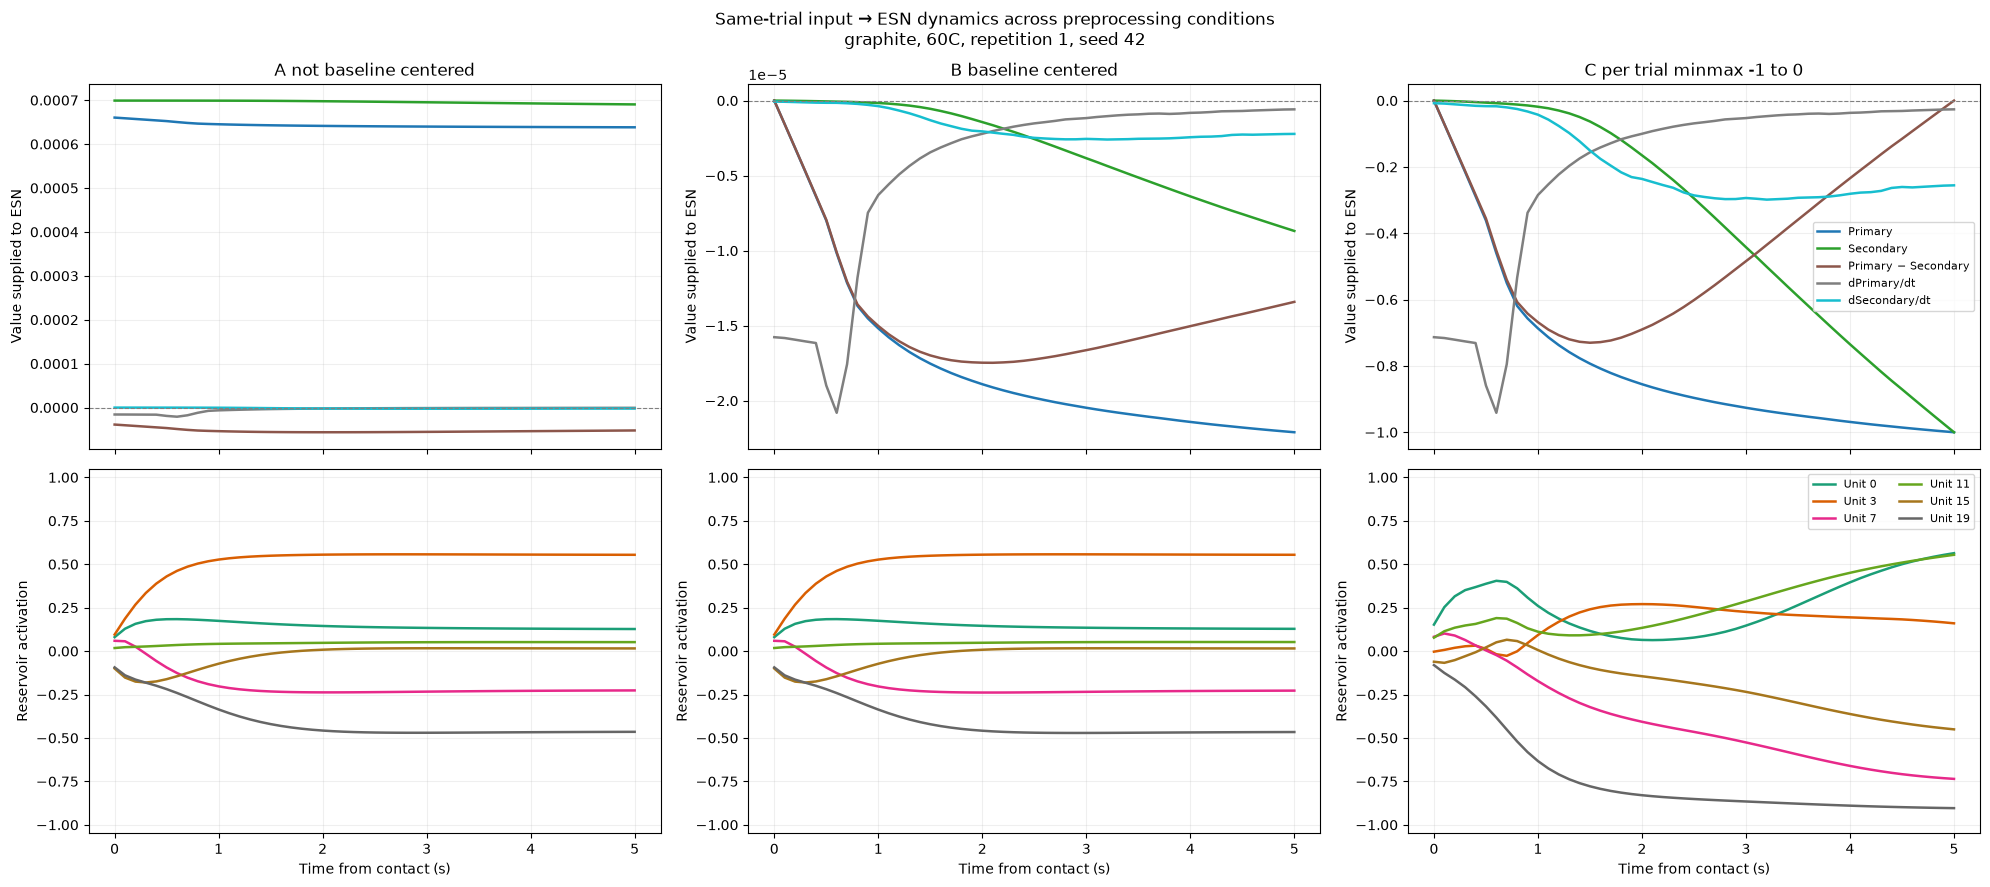

Example trial: 60C__graphite_trial_1
Interpretation reminder: the same reservoir is used in every column; only the input representation changes.


In [106]:
# Customize this example without rerunning the LOMO evaluation.
CONDITION_EXAMPLE_MATERIAL = "graphite"
CONDITION_EXAMPLE_TEMPERATURE = "60C"
CONDITION_EXAMPLE_TRIAL = 1
CONDITION_EXAMPLE_SEED = 42
CONDITION_EXAMPLE_UNITS = (0, 3, 7, 11, 15, 19)

selection = METADATA[
    (METADATA["Sample"] == CONDITION_EXAMPLE_MATERIAL)
    & (METADATA["Temperature"] == CONDITION_EXAMPLE_TEMPERATURE)
    & (METADATA["Trial"] == CONDITION_EXAMPLE_TRIAL)
]
if selection.empty:
    available = (
        METADATA[["Sample", "Temperature", "Trial"]]
        .drop_duplicates().sort_values(["Sample", "Temperature", "Trial"])
    )
    raise KeyError(
        "Requested example trial was not found. Available selections include:\n"
        + available.head(25).to_string(index=False)
    )

example_trial_id = selection.iloc[0]["trial_id"]
example_trial = aligned_trials[example_trial_id]
example_time = example_trial["time_from_contact"].to_numpy(float)

input_names = (
    "Primary", "Secondary", "Primary − Secondary",
    "dPrimary/dt", "dSecondary/dt",
)
input_colors = plt.cm.tab10(np.linspace(0, 1, len(input_names)))
unit_colors = plt.cm.Dark2(np.linspace(0, 1, len(CONDITION_EXAMPLE_UNITS)))

fig, axes = plt.subplots(
    2, len(CONDITIONS), figsize=(20, 9), sharex="col", squeeze=False
)

for column, (condition, input_mode) in enumerate(CONDITIONS.items()):
    sequence = esn_input(example_trial, input_mode)
    reservoir = ManualReservoir(CONDITION_EXAMPLE_SEED)
    states = reservoir.run(sequence)
    state_time = example_time[ESN_PARAMS["washout"]:]

    for channel, name in enumerate(input_names):
        axes[0, column].plot(
            example_time, sequence[:, channel],
            color=input_colors[channel], linewidth=1.8, label=name,
        )
    axes[0, column].axhline(0, color="gray", linestyle="--", linewidth=.8)
    axes[0, column].set_title(condition.replace("_", " "))
    axes[0, column].set_ylabel("Value supplied to ESN")
    axes[0, column].grid(alpha=.20)

    for unit_index, unit in enumerate(CONDITION_EXAMPLE_UNITS):
        if unit >= states.shape[1]:
            raise IndexError(
                f"Requested Unit {unit}, but the reservoir has {states.shape[1]} units."
            )
        axes[1, column].plot(
            state_time, states[:, unit],
            color=unit_colors[unit_index], linewidth=1.8, label=f"Unit {unit}",
        )
    axes[1, column].set_xlabel("Time from contact (s)")
    axes[1, column].set_ylabel("Reservoir activation")
    axes[1, column].set_ylim(-1.05, 1.05)
    axes[1, column].grid(alpha=.20)

axes[0, -1].legend(fontsize=8, loc="best")
axes[1, -1].legend(fontsize=8, ncol=2, loc="best")
fig.suptitle(
    "Same-trial input → ESN dynamics across preprocessing conditions\n"
    f"{CONDITION_EXAMPLE_MATERIAL}, {CONDITION_EXAMPLE_TEMPERATURE}, "
    f"repetition {CONDITION_EXAMPLE_TRIAL}, seed {CONDITION_EXAMPLE_SEED}"
)
plt.tight_layout()
plt.show()

print("Example trial:", example_trial_id)
print(
    "Interpretation reminder: the same reservoir is used in every column; "
    "only the input representation changes."
)


# 6. Leakage-safe paired LOMO evaluation

No input scaler is fitted. After common smoothing, each condition-specific five-channel representation is supplied directly to the fixed reservoir. All three conditions use exactly the same held-out material, LOMO split, reservoir matrices, summaries, and regressor settings.

In [107]:
def make_regressor(random_state):
    xgb = XGBRegressor(
        objective="reg:squarederror", random_state=int(random_state),
        n_jobs=-1, tree_method="hist", verbosity=0, **XGB_PARAMS,
    )
    base = Pipeline([("imputer", SimpleImputer(strategy="median")), ("xgb", xgb)])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )

def pooled_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true), "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse, "nrmse_range": rmse/target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true-y_pred)/y_true))*100),
    }

def feature_table(train_ids, all_ids, input_mode, seed):
    # train_ids is retained in the API to keep fold construction explicit,
    # but no scaler is fitted: each condition enters the ESN directly.
    reservoir = ManualReservoir(seed)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = esn_input(trial, input_mode)
        states = reservoir.run(sequence)
        time = trial["time_from_contact"].to_numpy(float)[ESN_PARAMS["washout"]:]
        row = summarize_states(time, states)
        row["trial_id"] = trial_id
        rows.append(row)
    return pd.DataFrame(rows).set_index("trial_id")

logo = LeaveOneGroupOut()
prediction_rows, fold_rows = [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(METADATA, groups=METADATA["Sample"]), start=1):
    train_meta, test_meta = METADATA.iloc[train_idx], METADATA.iloc[test_idx]
    train_ids, test_ids = train_meta["trial_id"].tolist(), test_meta["trial_id"].tolist()
    y_train, y_test = train_meta[TARGET].to_numpy(float), test_meta[TARGET].to_numpy(float)
    material = test_meta["Sample"].iloc[0]
    print(f"Fold {fold:02d}/14: held out {material}")

    for condition, input_mode in CONDITIONS.items():
        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = feature_table(train_ids, train_ids + test_ids, input_mode, seed)
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                pred = np.clip(pred, y_train.min(), y_train.max())
            seed_predictions.append(pred)
        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual**2)))
        fold_rows.append({
            "condition": condition, "fold": fold, "held_out_material": material,
            "n": len(y_test), "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
            "nrmse_training_range": rmse/float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual/y_test))*100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "condition": condition, "fold": fold, "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"], "Sample": meta_row["Sample"],
                "Trial": meta_row["Trial"], "y_true": y_test[row_index],
                "y_pred": prediction[row_index],
            })

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"condition": condition, **pooled_metrics(part["y_true"], part["y_pred"])}
    for condition, part in OOF.groupby("condition", sort=False)
])
display(OVERALL)


Fold 01/14: held out aluminum
Fold 02/14: held out bismuth
Fold 03/14: held out cement
Fold 04/14: held out copper
Fold 05/14: held out cork
Fold 06/14: held out graphite
Fold 07/14: held out gypsum
Fold 08/14: held out iron
Fold 09/14: held out nickel
Fold 10/14: held out pdms
Fold 11/14: held out ps_foam
Fold 12/14: held out pu_foam
Fold 13/14: held out titanium
Fold 14/14: held out wood


,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,A_not_baseline_centered,336,4665.265906,8379.322805,0.225505,0.441085,53.090326
1,B_baseline_centered,336,5216.292635,9028.340776,0.242971,0.351151,64.729320
2,C_per_trial_minmax_-1_to_0,336,5231.336601,9134.295229,0.245822,0.335832,64.525579


# 7. Paired performance comparison

rmse                      \
condition         A_not_baseline_centered B_baseline_centered   
held_out_material                                               
titanium                      7364.130529         5592.787286   
graphite                      4595.022329         3401.669337   
cement                        2694.755439         2250.765570   
gypsum                        3423.734501         3195.503756   
ps_foam                        230.740459          139.892489   
cork                           119.801082          231.283028   
pu_foam                        327.658739          525.523817   
pdms                           212.815505          411.893913   
bismuth                       9192.425474        10285.618699   
copper                       25182.260478        25909.251431   
iron                          4953.320667         6643.372519   
nickel                        5875.172373         7710.031853   
aluminum                     10490.947380        12484.769867   
wood                           821.102901         6780.463323   

                                                nrmse_training_range  \
condition         C_per_trial_minmax_-1_to_0 A_not_baseline_centered   
held_out_material                                                      
titanium                         7483.488033                0.198184   
graphite                         5828.952201                0.123661   
cement                            241.733385                0.072521   
gypsum                            267.422173                0.092140   
ps_foam                           164.013754                0.006211   
cork                              252.261372                0.003224   
pu_foam                           450.584906                0.008818   
pdms                              281.911670                0.005727   
bismuth                         11983.744936                0.247387   
copper                          26420.038728                1.052612   
iron                             6174.115880                0.133304   
nickel                           7340.919452                0.158113   
aluminum                        11904.621426                0.282333   
wood                             1501.739408                0.022098   

                                                                  \
condition         B_baseline_centered C_per_trial_minmax_-1_to_0   
held_out_material                                                  
titanium                     0.150513                   0.201396   
graphite                     0.091546                   0.156869   
cement                       0.060573                   0.006506   
gypsum                       0.085997                   0.007197   
ps_foam                      0.003766                   0.004415   
cork                         0.006224                   0.006789   
pu_foam                      0.014143                   0.012126   
pdms                         0.011085                   0.007587   
bismuth                      0.276807                   0.322507   
copper                       1.083000                   1.104351   
iron                         0.178787                   0.166158   
nickel                       0.207493                   0.197559   
aluminum                     0.335990                   0.320378   
wood                         0.182476                   0.040415   

                           median_ape_pct                      \
condition         A_not_baseline_centered B_baseline_centered   
held_out_material                                               
titanium                        41.116546           61.480315   
graphite                        20.166351           23.203599   
cement                          33.382099           41.864011   
gypsum                          47.447613          323.664597   
ps_foam                        215.731207          287.625511   
cork                         

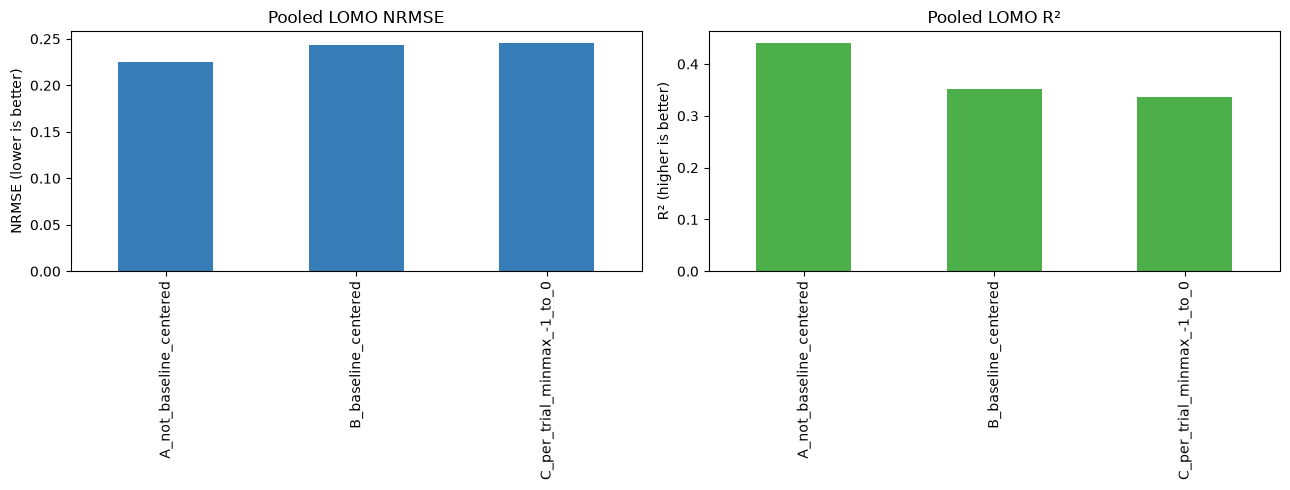

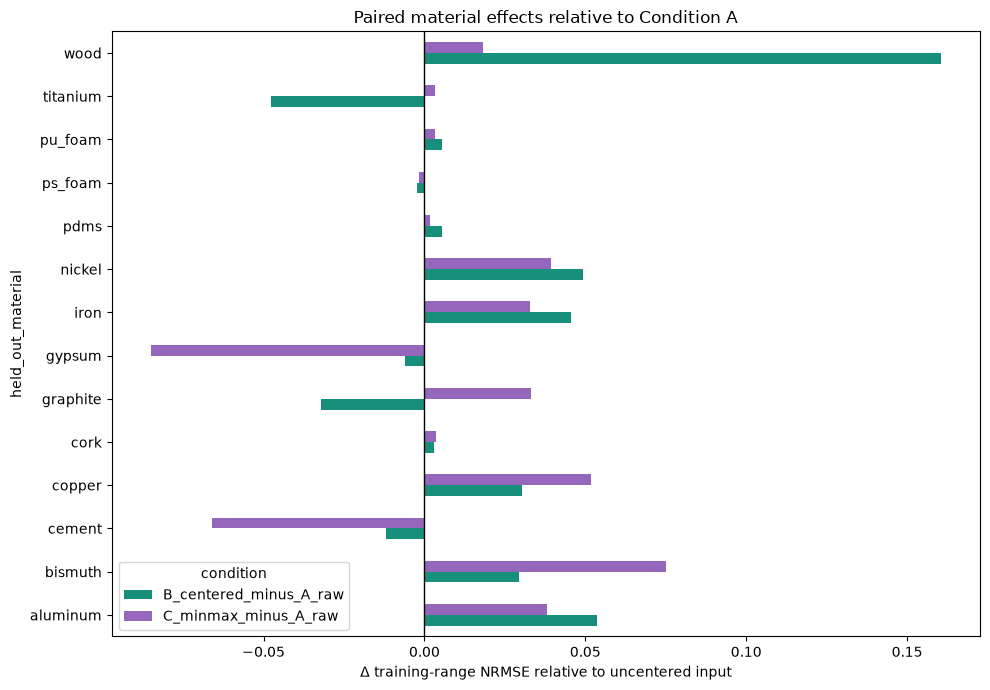

Negative Δ means that preprocessing condition improved the held-out material relative to Condition A.


In [108]:
paired_folds = FOLD_METRICS.pivot(index="held_out_material", columns="condition", values=["rmse", "nrmse_training_range", "median_ape_pct"])
paired_folds[("delta", "B_centered_minus_A_raw")] = (
    paired_folds[("nrmse_training_range", "B_baseline_centered")]
    - paired_folds[("nrmse_training_range", "A_not_baseline_centered")]
)
paired_folds[("delta", "C_minmax_minus_A_raw")] = (
    paired_folds[("nrmse_training_range", "C_per_trial_minmax_-1_to_0")]
    - paired_folds[("nrmse_training_range", "A_not_baseline_centered")]
)
display(paired_folds.sort_values(("delta", "B_centered_minus_A_raw")))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary_plot = OVERALL.set_index("condition")
summary_plot[["nrmse_range"]].plot(kind="bar", legend=False, ax=axes[0], color="#377eb8")
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE (lower is better)", xlabel="")
summary_plot[["r2"]].plot(kind="bar", legend=False, ax=axes[1], color="#4daf4a")
axes[1].set(title="Pooled LOMO R²", ylabel="R² (higher is better)", xlabel="")
plt.tight_layout(); plt.show()

deltas = paired_folds["delta"].sort_index()
ax = deltas.plot(kind="barh", figsize=(10, 7), color=["#188F7A", "#9467bd"])
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Paired material effects relative to Condition A", xlabel="Δ training-range NRMSE relative to uncentered input")
plt.tight_layout(); plt.show()
print("Negative Δ means that preprocessing condition improved the held-out material relative to Condition A.")


# 8. Input-to-dynamics comparison using all repetitions

Choose one material and temperature. Every available repetition is transformed and passed through the reservoir independently. The same input channel or reservoir unit is then averaged across repetitions, and the shaded region shows ±1 repetition SD. Trials are never averaged before the nonlinear ESN transformation.

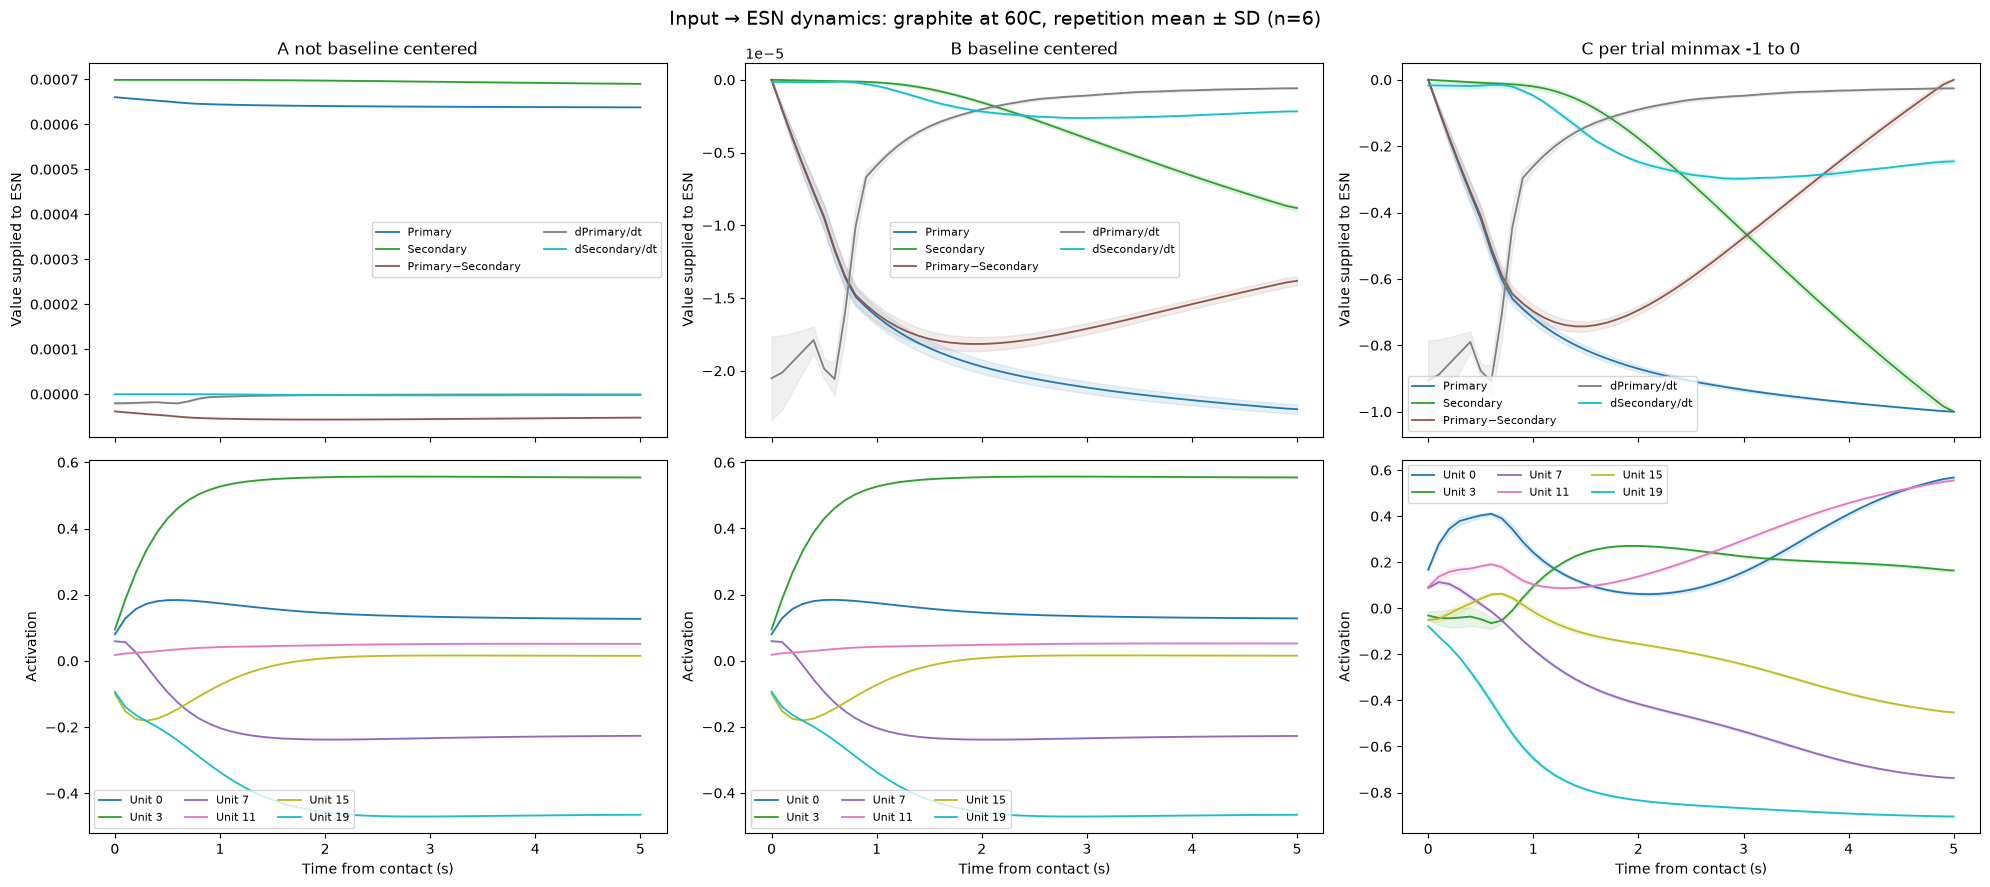

,condition,n_repetitions,mean_rms_activation_mean,mean_rms_activation_sd,mean_absolute_activation_mean,mean_absolute_activation_sd,fraction_near_saturation_abs_gt_0.95_mean,fraction_near_saturation_abs_gt_0.95_sd
0,A_not_baseline_centered,6,0.308466,0.000279,0.266796,0.000220,0.0,0.0
1,B_baseline_centered,6,0.308588,0.000280,0.267018,0.000221,0.0,0.0
2,C_per_trial_minmax_-1_to_0,6,0.438732,0.003038,0.378708,0.002897,0.0,0.0


In [109]:
DIAGNOSTIC_MATERIAL = "graphite"
DIAGNOSTIC_TEMPERATURE = "60C"
DIAGNOSTIC_SEED = 42
REPRESENTATIVE_UNITS = (0, 3, 7, 11, 15, 19)
DIAGNOSTIC_GRID_POINTS = 101

selected = (METADATA[(METADATA["Sample"] == DIAGNOSTIC_MATERIAL)
                     & (METADATA["Temperature"] == DIAGNOSTIC_TEMPERATURE)]
            .sort_values("Trial"))
if selected.empty:
    raise KeyError("The requested diagnostic material and temperature were not found.")
selected_ids = selected["trial_id"].tolist()
common_time = np.linspace(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1], DIAGNOSTIC_GRID_POINTS)

# Process every repetition independently before averaging.
diagnostics = {}
for condition, input_mode in CONDITIONS.items():
    reservoir = ManualReservoir(DIAGNOSTIC_SEED)
    repetition_inputs = []
    repetition_states = []
    repetition_activity = []
    for trial_id in selected_ids:
        trial = aligned_trials[trial_id]
        original_time = trial["time_from_contact"].to_numpy(float)
        represented = esn_input(trial, input_mode)
        states = reservoir.run(represented)
        repetition_inputs.append(np.column_stack([
            np.interp(common_time, original_time, represented[:, channel])
            for channel in range(represented.shape[1])
        ]))
        repetition_states.append(np.column_stack([
            np.interp(common_time, original_time, states[:, unit])
            for unit in range(states.shape[1])
        ]))
        repetition_activity.append({
            "mean_rms_activation": float(np.mean(np.sqrt(np.mean(states**2, axis=1)))),
            "mean_absolute_activation": float(np.mean(np.abs(states))),
            "fraction_near_saturation_abs_gt_0.95": float(np.mean(np.abs(states) > 0.95)),
        })
    input_stack = np.asarray(repetition_inputs)
    state_stack = np.asarray(repetition_states)
    diagnostics[condition] = {
        "input_mean": input_stack.mean(axis=0),
        "input_sd": input_stack.std(axis=0, ddof=1),
        "state_mean": state_stack.mean(axis=0),
        "state_sd": state_stack.std(axis=0, ddof=1),
        "activity_by_repetition": pd.DataFrame(repetition_activity),
    }

fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharex=True)
channel_names = ["Primary", "Secondary", "Primary−Secondary", "dPrimary/dt", "dSecondary/dt"]
channel_colors = plt.cm.tab10(np.linspace(0, 1, len(channel_names)))
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(REPRESENTATIVE_UNITS)))
for column, (condition, values) in enumerate(diagnostics.items()):
    for channel, name in enumerate(channel_names):
        mean = values["input_mean"][:, channel]
        sd = values["input_sd"][:, channel]
        color = channel_colors[channel]
        axes[0, column].plot(common_time, mean, color=color, label=name, linewidth=1.3)
        axes[0, column].fill_between(common_time, mean-sd, mean+sd, color=color, alpha=0.11)
    axes[0, column].set(title=condition.replace("_", " "), ylabel="Value supplied to ESN")
    axes[0, column].legend(fontsize=8, ncol=2)
    for unit_index, unit in enumerate(REPRESENTATIVE_UNITS):
        mean = values["state_mean"][:, unit]
        sd = values["state_sd"][:, unit]
        color = unit_colors[unit_index]
        axes[1, column].plot(common_time, mean, color=color, linewidth=1.3, label=f"Unit {unit}")
        axes[1, column].fill_between(common_time, mean-sd, mean+sd, color=color, alpha=0.11)
    axes[1, column].set(xlabel="Time from contact (s)", ylabel="Activation")
    axes[1, column].legend(fontsize=8, ncol=3)
fig.suptitle(
    f"Input → ESN dynamics: {DIAGNOSTIC_MATERIAL} at {DIAGNOSTIC_TEMPERATURE}, "
    f"repetition mean ± SD (n={len(selected_ids)})", fontsize=14,
)
plt.tight_layout(); plt.show()

activity_rows = []
for condition, values in diagnostics.items():
    per_repetition = values["activity_by_repetition"]
    row = {"condition": condition, "n_repetitions": len(per_repetition)}
    for metric in per_repetition.columns:
        row[f"{metric}_mean"] = float(per_repetition[metric].mean())
        row[f"{metric}_sd"] = float(per_repetition[metric].std(ddof=1))
    activity_rows.append(row)
display(pd.DataFrame(activity_rows))


# 9. Actual-versus-predicted and material-mean behavior

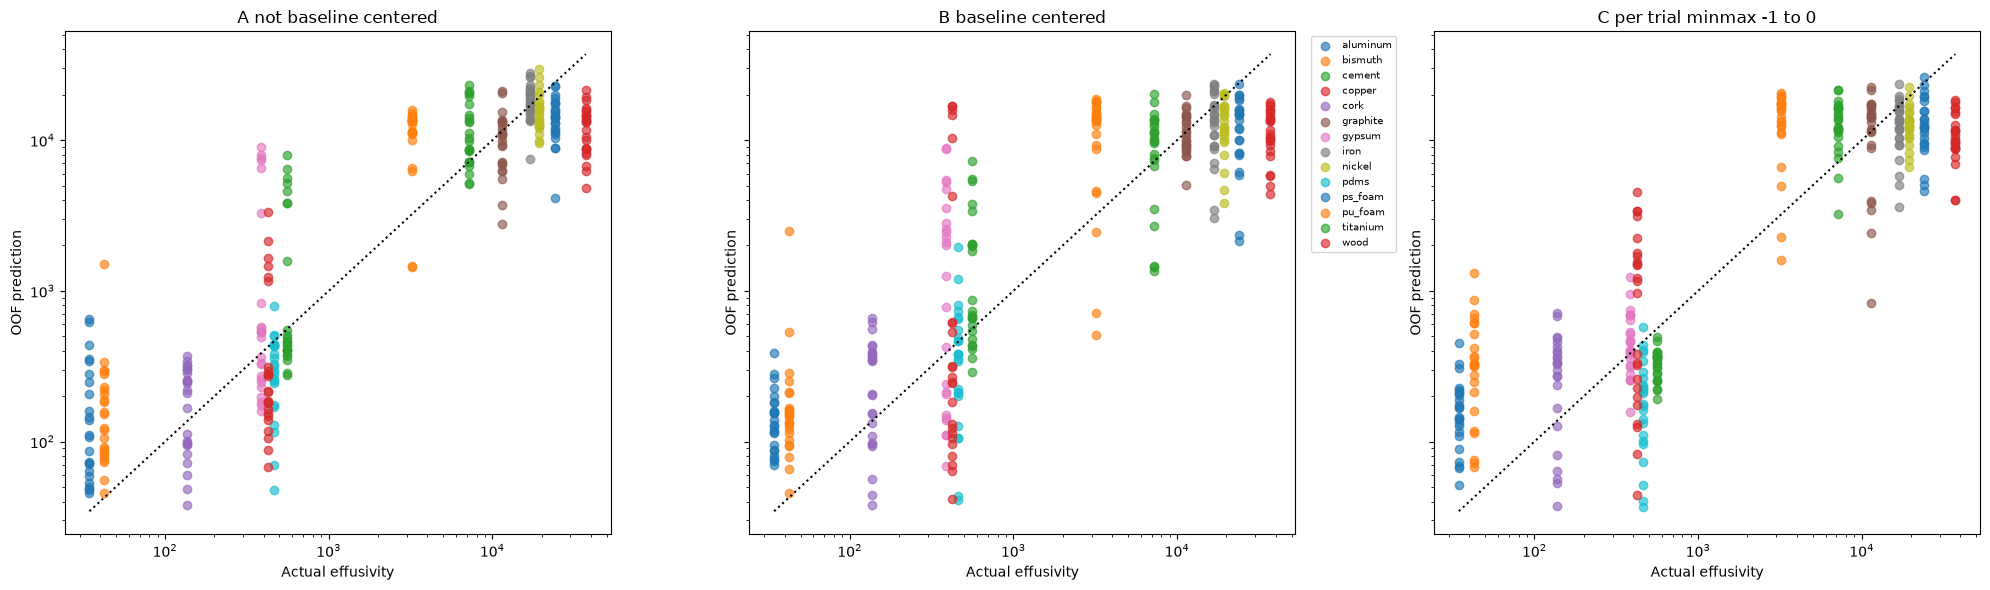

LOMO performance after averaging 24 OOF trials per material:


,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,A_not_baseline_centered,14,4073.584109,7649.553687,0.205865,0.534199,54.358314
1,B_baseline_centered,14,4572.073072,8126.519187,0.218701,0.474301,86.291175
2,C_per_trial_minmax_-1_to_0,14,4767.533441,8467.556594,0.227879,0.429252,61.996893


In [110]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
for ax, (condition, part) in zip(axes, OOF.groupby("condition", sort=False)):
    for material, material_part in part.groupby("Sample"):
        ax.scatter(material_part["y_true"], material_part["y_pred"], alpha=0.65, label=material)
    low = min(part["y_true"].min(), part["y_pred"].min())
    high = max(part["y_true"].max(), part["y_pred"].max())
    ax.plot([low, high], [low, high], "k:")
    ax.set(xscale="log", yscale="log", title=condition.replace("_", " "), xlabel="Actual effusivity", ylabel="OOF prediction")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

MATERIAL_MEANS = OOF.groupby(["condition", "Sample"], as_index=False).agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"), prediction_sd=("y_pred", "std"), n=("trial_id", "size"))
MATERIAL_LEVEL_RESULTS = pd.DataFrame([
    {"condition": condition, **pooled_metrics(part["y_true"], part["y_pred"])}
    for condition, part in MATERIAL_MEANS.groupby("condition", sort=False)
])
print("LOMO performance after averaging 24 OOF trials per material:")
display(MATERIAL_LEVEL_RESULTS)


# 10. Selected-material input → ESN dynamics → LOMO OOF correspondence

This reproduces the requested presentation style for any one preprocessing condition. Each material block shows its actual and OOF-predicted effusivity, condition-specific sensor representation, and representative reservoir trajectories. Lines are repetition means and shading is ±1 repetition SD.

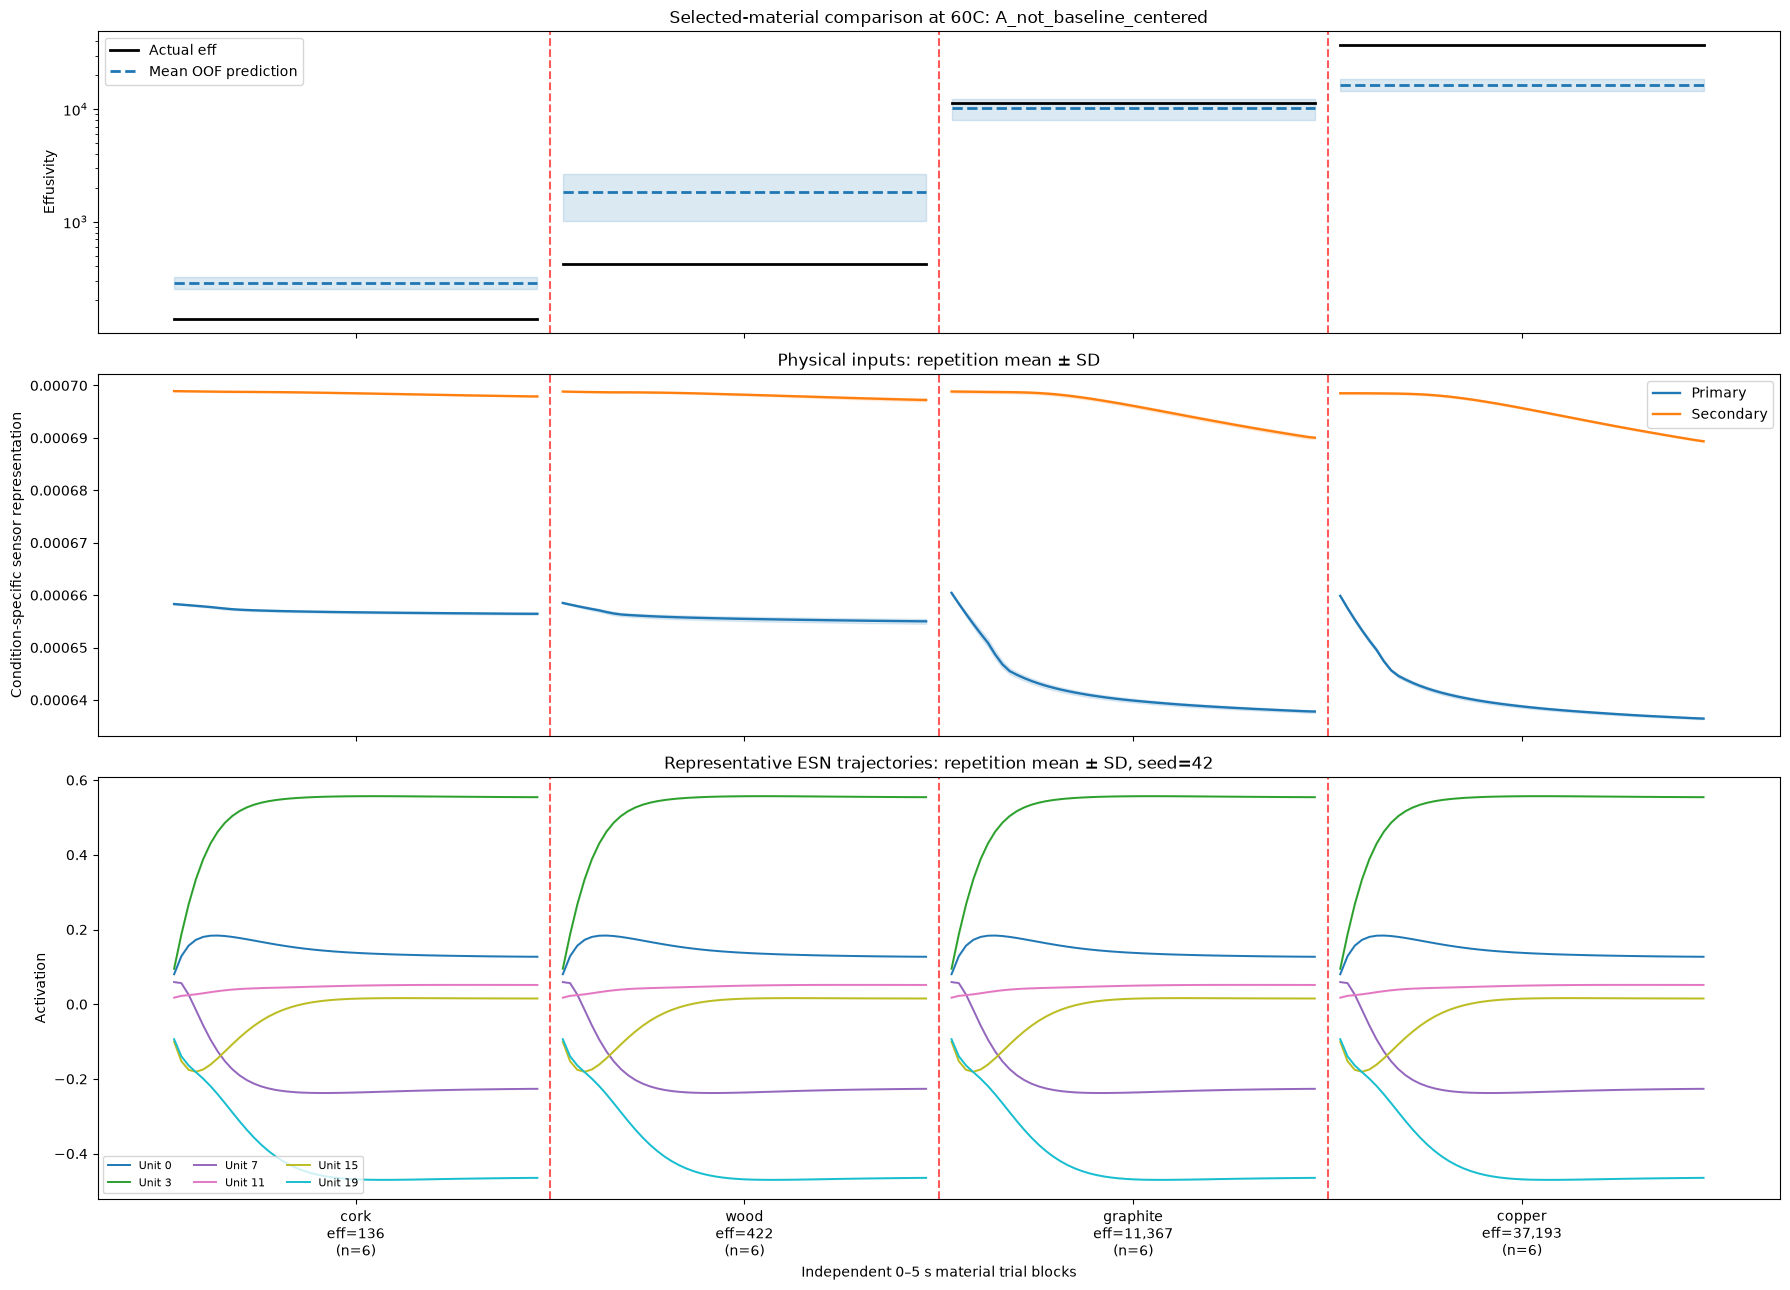

In [111]:
CONDITIONS = {
    "A_not_baseline_centered": "raw",
    "B_baseline_centered": "baseline_centered",
    "C_per_trial_minmax_-1_to_0": "minmax_-1_to_0",
}

CASE_STUDY_CONDITION = "A_not_baseline_centered"  # choose any key in CONDITIONS
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["cork", "wood", "graphite", "copper"]
CASE_STUDY_SEED = 42
CASE_STUDY_UNITS = (0, 3, 7, 11, 15, 19)
CASE_STUDY_GRID_POINTS = 101

if CASE_STUDY_CONDITION not in CONDITIONS:
    raise KeyError(f"Unknown condition. Choose from {list(CONDITIONS)}")
case_mode = CONDITIONS[CASE_STUDY_CONDITION]
case_grid = np.linspace(*ANALYSIS_WINDOW, CASE_STUDY_GRID_POINTS)
block_length = ANALYSIS_WINDOW[1] - ANALYSIS_WINDOW[0]
gap = 0.35

fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True, gridspec_kw={"height_ratios": [1.0, 1.2, 1.4]})
material_labels = []
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(CASE_STUDY_UNITS)))
for block, material in enumerate(CASE_STUDY_MATERIALS):
    selected_meta = METADATA[(METADATA["Sample"] == material) & (METADATA["Temperature"] == CASE_STUDY_TEMPERATURE)].sort_values("Trial")
    if selected_meta.empty:
        warnings.warn(f"No trials found for {material} at {CASE_STUDY_TEMPERATURE}")
        continue
    selected_ids = selected_meta["trial_id"].tolist()
    x_offset = block * (block_length + gap)
    x = x_offset + case_grid

    # Trial-level LOMO predictions already produced by the paired evaluation.
    prediction_part = OOF[(OOF["condition"] == CASE_STUDY_CONDITION) & (OOF["Sample"] == material) & (OOF["Temperature"] == CASE_STUDY_TEMPERATURE)]
    actual = float(selected_meta[TARGET].iloc[0])
    predicted_mean = float(prediction_part["y_pred"].mean())
    predicted_sd = float(prediction_part["y_pred"].std(ddof=1))
    axes[0].plot([x[0], x[-1]], [actual, actual], color="black", linewidth=2.0, label="Actual eff" if block == 0 else None)
    axes[0].plot([x[0], x[-1]], [predicted_mean, predicted_mean], color="#1f77b4", linestyle="--", linewidth=2.0, label="Mean OOF prediction" if block == 0 else None)
    axes[0].fill_between(x, max(predicted_mean-predicted_sd, 1e-12), predicted_mean+predicted_sd, color="#1f77b4", alpha=0.16)

    # No fold scaler is used; the selected condition is supplied directly.
    sensor_trials = []
    state_trials = []
    for selected_id in selected_ids:
        selected_trial = aligned_trials[selected_id]
        original_time = selected_trial["time_from_contact"].to_numpy(float)
        represented = esn_input(selected_trial, case_mode)
        sensor_trials.append(np.column_stack([
            np.interp(case_grid, original_time, represented[:, 0]),
            np.interp(case_grid, original_time, represented[:, 1]),
        ]))
        states = ManualReservoir(CASE_STUDY_SEED).run(represented)
        state_trials.append(np.column_stack([
            np.interp(case_grid, original_time, states[:, unit]) for unit in CASE_STUDY_UNITS
        ]))

    sensor_trials = np.asarray(sensor_trials)
    state_trials = np.asarray(state_trials)
    sensor_mean, sensor_sd = sensor_trials.mean(axis=0), sensor_trials.std(axis=0, ddof=1)
    state_mean, state_sd = state_trials.mean(axis=0), state_trials.std(axis=0, ddof=1)
    for channel, (name, color) in enumerate((("Primary", "#1f77b4"), ("Secondary", "#ff7f0e"))):
        axes[1].plot(x, sensor_mean[:, channel], color=color, linewidth=1.7, label=name if block == 0 else None)
        axes[1].fill_between(x, sensor_mean[:, channel]-sensor_sd[:, channel], sensor_mean[:, channel]+sensor_sd[:, channel], color=color, alpha=0.13)
    for unit_index, unit in enumerate(CASE_STUDY_UNITS):
        color = unit_colors[unit_index]
        axes[2].plot(x, state_mean[:, unit_index], color=color, linewidth=1.4, label=f"Unit {unit}" if block == 0 else None)
        axes[2].fill_between(x, state_mean[:, unit_index]-state_sd[:, unit_index], state_mean[:, unit_index]+state_sd[:, unit_index], color=color, alpha=0.10)

    material_labels.append((x_offset + block_length/2, f"{material}\neff={actual:,.0f}\n(n={len(selected_ids)})"))
    if block < len(CASE_STUDY_MATERIALS)-1:
        boundary = x_offset + block_length + gap/2
        for ax in axes:
            ax.axvline(boundary, color="red", linestyle="--", alpha=0.65)

axes[0].set(yscale="log", ylabel="Effusivity", title=f"Selected-material comparison at {CASE_STUDY_TEMPERATURE}: {CASE_STUDY_CONDITION}")
axes[0].legend(loc="best")
axes[1].set(ylabel="Condition-specific sensor representation", title="Physical inputs: repetition mean ± SD")
axes[1].legend(loc="best")
axes[2].set(ylabel="Activation", title=f"Representative ESN trajectories: repetition mean ± SD, seed={CASE_STUDY_SEED}")
axes[2].legend(ncol=3, fontsize=8)
axes[2].set_xticks([position for position, _ in material_labels], [label for _, label in material_labels])
axes[2].set_xlabel("Independent 0–5 s material trial blocks")
plt.tight_layout(); plt.show()


# 11. Condition A feature-channel ablation

This controlled analysis is restricted to **Condition A: direct absolute smoothed inputs**. It
tests which physical signal components account for its prediction performance. Every case retains
the same folds, targets, reservoir seeds, recurrent weights, ESN hyperparameters, trajectory
summaries, and XGBoost settings.

The nine cases are: `P + S + Δ(P,S) + dP/dt + dS/dt`, the same five inputs plus
`d²P/dt² + d²S/dt²`, `P + Δ(P,S) + dP/dt`, `S + Δ(P,S) + dS/dt`,
`P + dP/dt`, `S + dS/dt`, `Δ(P,S)`, `P`, and `S`.

The common input channels use the same columns of one five-input reservoir realization. This
prevents a different random reservoir from being mistaken for a channel effect.

In [112]:
CHANNEL_CONDITION = "A_not_baseline_centered"
CHANNEL_INPUT_MODE = CONDITIONS[CHANNEL_CONDITION]
CHANNEL_SETS = {
    "P_S_delta_dP_dS": {"sequence_columns": (0, 1, 2, 3, 4), "win_columns": (0, 1, 2, 3, 4, 5)},
    "P_S_delta_dP_dS_ddP_ddS": {"sequence_columns": (0, 1, 2, 3, 4, 5, 6), "win_columns": (0, 1, 2, 3, 4, 5, 6, 7)},
    "P_delta_dP": {"sequence_columns": (0, 2, 3), "win_columns": (0, 1, 3, 4)},
    "S_delta_dS": {"sequence_columns": (1, 2, 4), "win_columns": (0, 2, 3, 5)},
    "P_dP": {"sequence_columns": (0, 3), "win_columns": (0, 1, 4)},
    "S_dS": {"sequence_columns": (1, 4), "win_columns": (0, 2, 5)},
    "delta": {"sequence_columns": (2,), "win_columns": (0, 3)},
    "P": {"sequence_columns": (0,), "win_columns": (0, 1)},
    "S": {"sequence_columns": (1,), "win_columns": (0, 2)},
}

class ChannelMatchedReservoir:
    """One fixed full reservoir; channel ablations select columns from the same Win."""
    def __init__(self, random_state):
        rng = np.random.default_rng(random_state)
        base_Win = (rng.random((ESN_PARAMS["res_size"], 6)) - 0.5) * ESN_PARAMS["input_magnitude"]
        recurrent = rng.random((ESN_PARAMS["res_size"], ESN_PARAMS["res_size"])) - 0.5
        radius = np.max(np.abs(linalg.eigvals(recurrent)))
        self.W = (recurrent / radius.real) * ESN_PARAMS["spectral_radius"]
        # Generate the two new second-derivative weights independently so the original
        # five input weights and recurrent matrix remain exactly unchanged.
        extra_rng = np.random.default_rng(int(random_state) + 10000)
        extra_Win = (extra_rng.random((ESN_PARAMS["res_size"], 2)) - 0.5) * ESN_PARAMS["input_magnitude"]
        self.full_Win = np.column_stack([base_Win, extra_Win])

    def run(self, full_sequence, channel_spec):
        sequence = np.asarray(full_sequence, float)[:, channel_spec["sequence_columns"]]
        Win = self.full_Win[:, channel_spec["win_columns"]]
        x = np.zeros((ESN_PARAMS["res_size"], 1))
        states = []
        for row in sequence:
            proposed = np.tanh(Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x)
            x = (1-ESN_PARAMS["leak_rate"])*x + ESN_PARAMS["leak_rate"]*proposed
            states.append(x[:, 0].copy())
        return np.asarray(states)[ESN_PARAMS["washout"]:]

def channel_feature_table(all_ids, input_mode, channel_set, seed):
    reservoir = ChannelMatchedReservoir(seed)
    channel_spec = CHANNEL_SETS[channel_set]
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        represented = esn_input(trial, input_mode)
        time = trial["time_from_contact"].to_numpy(float)
        extended = np.column_stack([
            represented, np.gradient(represented[:, 3], time), np.gradient(represented[:, 4], time)
        ])
        states = reservoir.run(extended, channel_spec)
        summary_time = time[ESN_PARAMS["washout"]:]
        row = summarize_states(summary_time, states)
        row["trial_id"] = trial_id
        rows.append(row)
    return pd.DataFrame(rows).set_index("trial_id")

# These features require no fold-fitted scaler, so compute each deterministic table once.
all_trial_ids = METADATA["trial_id"].tolist()
CHANNEL_FEATURE_CACHE = {}
for channel_set in CHANNEL_SETS:
    for seed in RESERVOIR_SEEDS:
        cache_key = (channel_set, seed)
        CHANNEL_FEATURE_CACHE[cache_key] = channel_feature_table(
            all_trial_ids, CHANNEL_INPUT_MODE, channel_set, seed
        )

channel_prediction_rows = []
for fold, (train_idx, test_idx) in enumerate(logo.split(METADATA, groups=METADATA["Sample"]), start=1):
    train_meta, test_meta = METADATA.iloc[train_idx], METADATA.iloc[test_idx]
    train_ids, test_ids = train_meta["trial_id"].tolist(), test_meta["trial_id"].tolist()
    y_train, y_test = train_meta[TARGET].to_numpy(float), test_meta[TARGET].to_numpy(float)
    print(f"Channel diagnostic fold {fold:02d}/14: held out {test_meta['Sample'].iloc[0]}")
    for channel_set in CHANNEL_SETS:
        if channel_set == "P_S_delta_dP_dS":
            continue  # Reuse the already-computed original Condition A OOF prediction.
        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = CHANNEL_FEATURE_CACHE[(channel_set, seed)]
            model = make_regressor(seed)
            model.fit(features.loc[train_ids].reset_index(drop=True), y_train)
            pred = model.predict(features.loc[test_ids].reset_index(drop=True))
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                pred = np.clip(pred, y_train.min(), y_train.max())
            seed_predictions.append(pred)
        prediction = np.mean(seed_predictions, axis=0)
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            channel_prediction_rows.append({
                "condition": CHANNEL_CONDITION, "channel_set": channel_set, "fold": fold,
                "trial_id": meta_row["trial_id"], "Temperature": meta_row["Temperature"],
                "Sample": meta_row["Sample"], "Trial": meta_row["Trial"],
                "y_true": y_test[row_index], "y_pred": prediction[row_index],
            })

CHANNEL_OOF = pd.DataFrame(channel_prediction_rows)
combined_oof = OOF[OOF["condition"] == CHANNEL_CONDITION].copy()
combined_oof["channel_set"] = "P_S_delta_dP_dS"
CHANNEL_OOF = pd.concat([CHANNEL_OOF, combined_oof[CHANNEL_OOF.columns]], ignore_index=True)
CHANNEL_OVERALL = pd.DataFrame([
    {"condition": condition, "channel_set": channel_set,
     **pooled_metrics(part["y_true"], part["y_pred"])}
    for (condition, channel_set), part in CHANNEL_OOF.groupby(["condition", "channel_set"], sort=False)
]).sort_values(["condition", "nrmse_range"]).reset_index(drop=True)
display(CHANNEL_OVERALL)


Channel diagnostic fold 01/14: held out aluminum
Channel diagnostic fold 02/14: held out bismuth
Channel diagnostic fold 03/14: held out cement
Channel diagnostic fold 04/14: held out copper
Channel diagnostic fold 05/14: held out cork
Channel diagnostic fold 06/14: held out graphite
Channel diagnostic fold 07/14: held out gypsum
Channel diagnostic fold 08/14: held out iron
Channel diagnostic fold 09/14: held out nickel
Channel diagnostic fold 10/14: held out pdms
Channel diagnostic fold 11/14: held out ps_foam
Channel diagnostic fold 12/14: held out pu_foam
Channel diagnostic fold 13/14: held out titanium
Channel diagnostic fold 14/14: held out wood


,condition,channel_set,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,A_not_baseline_centered,P_dP,336,4379.308709,7992.138035,0.215085,0.491543,53.065261
1,A_not_baseline_centered,P,336,4649.817659,8192.190480,0.220468,0.465770,54.515083
2,A_not_baseline_centered,P_delta_dP,336,4664.502163,8317.536048,0.223842,0.449297,52.299717
3,A_not_baseline_centered,P_S_delta_dP_dS,336,4665.265906,8379.322805,0.225505,0.441085,53.090326
4,A_not_baseline_centered,S_delta_dS,336,4884.646213,8516.060750,0.229184,0.422695,54.492712
5,A_not_baseline_centered,P_S_delta_dP_dS_ddP_ddS,336,4944.662125,8693.113433,0.233949,0.398440,56.570300
6,A_not_baseline_centered,delta,336,5117.251777,8769.009696,0.235992,0.387890,64.582893
7,A_not_baseline_centered,S,336,5259.975839,8956.457408,0.241036,0.361442,59.232423
8,A_not_baseline_centered,S_dS,336,5258.103935,9148.878494,0.246215,0.333709,61.751371


In [113]:
channel_order = ["P_S_delta_dP_dS", "P_S_delta_dP_dS_ddP_ddS",
                 "P_delta_dP", "S_delta_dS", "P_dP", "S_dS",
                 "delta", "P", "S"]
channel_labels = {
    "P_S_delta_dP_dS": "P + S + Δ(P,S) + dP/dt + dS/dt",
    "P_S_delta_dP_dS_ddP_ddS": "5 inputs + d²P/dt² + d²S/dt²",
    "P_delta_dP": "P + Δ(P,S) + dP/dt",
    "S_delta_dS": "S + Δ(P,S) + dS/dt",
    "P_dP": "P + dP/dt", "S_dS": "S + dS/dt",
    "delta": "Δ(P,S)",
    "P": "P", "S": "S",
}
channel_colors = dict(zip(channel_order, plt.cm.tab10(np.linspace(0, 0.9, len(channel_order)))))
CHANNEL_OVERALL = CHANNEL_OVERALL.set_index("channel_set").loc[channel_order].reset_index()
display(CHANNEL_OVERALL)

# A material has one fixed target, so its within-material target range is zero.
# Normalize its RMSE by the full 14-material target range instead. Per-material R² is
# intentionally omitted because it is undefined for a constant target.
GLOBAL_TARGET_RANGE = float(np.ptp(METADATA[TARGET].to_numpy(float)))
material_metric_rows = []
for (condition, channel_set, material), part in CHANNEL_OOF.groupby(
        ["condition", "channel_set", "Sample"], sort=False):
    y_true = part["y_true"].to_numpy(float)
    y_pred = part["y_pred"].to_numpy(float)
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual**2)))
    material_metric_rows.append({
        "condition": condition, "channel_set": channel_set,
        "held_out_material": material, "n": len(part),
        "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
        "nrmse_global_range": rmse / GLOBAL_TARGET_RANGE,
        "mean_error_bias": float(np.mean(residual)),
        "median_ape_pct": float(np.median(np.abs(residual / y_true)) * 100),
    })
CHANNEL_MATERIAL_METRICS = pd.DataFrame(material_metric_rows)
display(CHANNEL_MATERIAL_METRICS.sort_values(["condition", "channel_set", "nrmse_global_range"]))


,channel_set,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,P_S_delta_dP_dS,A_not_baseline_centered,336,4665.265906,8379.322805,0.225505,0.441085,53.090326
1,P_S_delta_dP_dS_ddP_ddS,A_not_baseline_centered,336,4944.662125,8693.113433,0.233949,0.398440,56.570300
2,P_delta_dP,A_not_baseline_centered,336,4664.502163,8317.536048,0.223842,0.449297,52.299717
3,S_delta_dS,A_not_baseline_centered,336,4884.646213,8516.060750,0.229184,0.422695,54.492712
4,P_dP,A_not_baseline_centered,336,4379.308709,7992.138035,0.215085,0.491543,53.065261
5,S_dS,A_not_baseline_centered,336,5258.103935,9148.878494,0.246215,0.333709,61.751371
6,delta,A_not_baseline_centered,336,5117.251777,8769.009696,0.235992,0.387890,64.582893
7,P,A_not_baseline_centered,336,4649.817659,8192.190480,0.220468,0.465770,54.515083
8,S,A_not_baseline_centered,336,5259.975839,8956.457408,0.241036,0.361442,59.232423


,condition,channel_set,held_out_material,n,mae,rmse,nrmse_global_range,mean_error_bias,median_ape_pct
86,A_not_baseline_centered,P,ps_foam,24,81.766553,124.522707,0.003351,81.766553,120.996467
38,A_not_baseline_centered,P,cork,24,106.241172,127.053489,0.003419,45.231685,65.943247
78,A_not_baseline_centered,P,pdms,24,246.352075,269.446066,0.007251,-116.769903,52.055368
110,A_not_baseline_centered,P,wood,24,305.876893,376.276166,0.010126,18.361880,69.417601
94,A_not_baseline_centered,P,pu_foam,24,253.477874,723.134082,0.019461,253.477874,254.222623
...,...,...,...,...,...,...,...,...,...
69,A_not_baseline_centered,delta,nickel,24,5821.405716,7137.966320,0.192097,-5650.726232,28.552735
101,A_not_baseline_centered,delta,titanium,24,6087.800010,7372.055308,0.198397,5739.168938,83.260797
5,A_not_baseline_centered,delta,aluminum,24,9281.202994,10185.154997,0.274103,-9263.129720,41.503953
13,A_not_baseline_centered,delta,bismuth,24,11494.240875,11911.697842,0.320568,11494.240875,362.906879


## 11A. Condition A prediction-performance comparison

Pooled metrics are trial-level LOMO results for the seven requested feature-channel combinations.
The next subsection compares their corresponding reservoir dynamics using the same Condition A
trials and matched reservoir realization.

,channel_set,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,P_S_delta_dP_dS,A_not_baseline_centered,336,4665.265906,8379.322805,0.225505,0.441085,53.090326
1,P_S_delta_dP_dS_ddP_ddS,A_not_baseline_centered,336,4944.662125,8693.113433,0.233949,0.398440,56.570300
2,P_delta_dP,A_not_baseline_centered,336,4664.502163,8317.536048,0.223842,0.449297,52.299717
3,S_delta_dS,A_not_baseline_centered,336,4884.646213,8516.060750,0.229184,0.422695,54.492712
4,P_dP,A_not_baseline_centered,336,4379.308709,7992.138035,0.215085,0.491543,53.065261
5,S_dS,A_not_baseline_centered,336,5258.103935,9148.878494,0.246215,0.333709,61.751371
6,delta,A_not_baseline_centered,336,5117.251777,8769.009696,0.235992,0.387890,64.582893
7,P,A_not_baseline_centered,336,4649.817659,8192.190480,0.220468,0.465770,54.515083
8,S,A_not_baseline_centered,336,5259.975839,8956.457408,0.241036,0.361442,59.232423


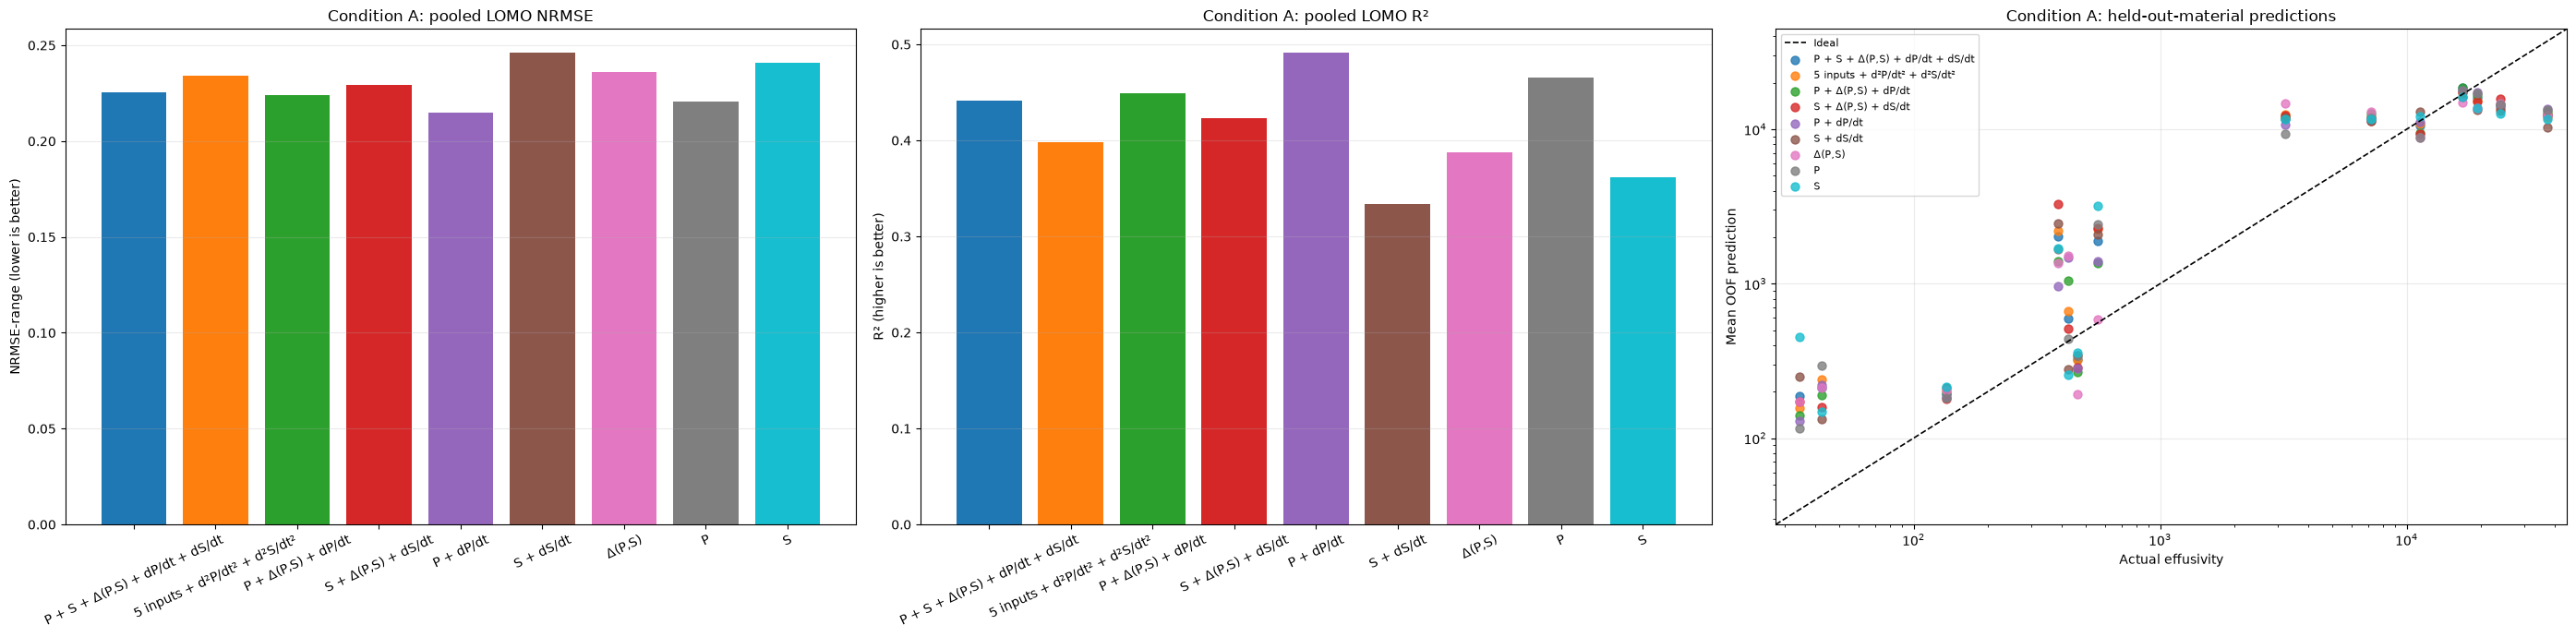

channel_set,P_S_delta_dP_dS,P_S_delta_dP_dS_ddP_ddS,P_delta_dP,S_delta_dS,P_dP,S_dS,delta,P,S
held_out_material,,,,,,,,,
aluminum,40.768596,44.024507,41.973584,35.517146,38.746001,45.829194,41.503953,37.703271,47.120618
bismuth,317.246770,343.520426,314.703671,303.456682,293.956429,285.624737,362.906879,261.027429,273.037871
cement,33.382099,38.764894,35.634926,41.007739,35.115269,53.465694,54.899196,41.956703,56.429920
copper,64.378348,68.191488,62.144998,66.217437,60.247421,68.958443,66.518547,63.704918,66.578425
cork,68.343039,65.727907,67.595004,43.029642,64.790179,50.777466,52.531739,65.943247,52.731218
graphite,20.166351,26.897135,31.765853,30.668554,29.293653,30.351637,48.282426,32.266242,33.297784
gypsum,47.447613,60.048065,27.313034,51.592512,54.383893,505.611976,55.737213,55.179603,280.537904
iron,18.368929,18.428633,20.987624,22.937997,17.706680,29.793048,21.814804,22.246445,26.542002
nickel,28.496121,27.731810,27.770527,32.458028,11.792069,30.901215,28.552735,28.897511,41.956933


,channel_set,nrmse_range,r2,delta_nrmse_vs_both,delta_r2_vs_both
0,P_S_delta_dP_dS,0.225505,0.441085,0.000000,0.000000
1,P_S_delta_dP_dS_ddP_ddS,0.233949,0.398440,0.008445,-0.042645
2,P_delta_dP,0.223842,0.449297,-0.001663,0.008212
3,S_delta_dS,0.229184,0.422695,0.003680,-0.018390
4,P_dP,0.215085,0.491543,-0.010420,0.050458
5,S_dS,0.246215,0.333709,0.020710,-0.107376
6,delta,0.235992,0.387890,0.010487,-0.053194
7,P,0.220468,0.465770,-0.005036,0.024685
8,S,0.241036,0.361442,0.015532,-0.079643


In [114]:
CONDITION_A = CHANNEL_CONDITION
A_CHANNEL_OVERALL = (CHANNEL_OVERALL[CHANNEL_OVERALL["condition"] == CONDITION_A]
                     .set_index("channel_set").loc[channel_order].reset_index())
display(A_CHANNEL_OVERALL)

fig, axes = plt.subplots(1, 3, figsize=(28, 7))
colors = [channel_colors[name] for name in channel_order]
labels = [channel_labels[name] for name in channel_order]
axes[0].bar(labels, A_CHANNEL_OVERALL["nrmse_range"], color=colors)
axes[0].set(title="Condition A: pooled LOMO NRMSE", ylabel="NRMSE-range (lower is better)")
axes[1].bar(labels, A_CHANNEL_OVERALL["r2"], color=colors)
axes[1].set(title="Condition A: pooled LOMO R²", ylabel="R² (higher is better)")
for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=25); ax.grid(axis="y", alpha=0.25)

a_oof = CHANNEL_OOF[CHANNEL_OOF["condition"] == CONDITION_A]
limits = [max(a_oof[["y_true", "y_pred"]].min().min()*0.8, 1e-9),
          a_oof[["y_true", "y_pred"]].max().max()*1.2]
axes[2].plot(limits, limits, color="black", linestyle="--", linewidth=1.2, label="Ideal")
for channel_set in channel_order:
    part = a_oof[a_oof["channel_set"] == channel_set]
    material_means = part.groupby("Sample", as_index=False)[["y_true", "y_pred"]].mean()
    axes[2].scatter(material_means["y_true"], material_means["y_pred"], s=42, alpha=0.8,
                    color=channel_colors[channel_set], label=channel_labels[channel_set])
axes[2].set(xscale="log", yscale="log", xlim=limits, ylim=limits,
            xlabel="Actual effusivity", ylabel="Mean OOF prediction",
            title="Condition A: held-out-material predictions")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)
plt.tight_layout(); plt.show()

A_MATERIAL_CHANNEL_METRICS = CHANNEL_MATERIAL_METRICS[
    CHANNEL_MATERIAL_METRICS["condition"] == CONDITION_A
].copy()
display(A_MATERIAL_CHANNEL_METRICS.pivot(
    index="held_out_material", columns="channel_set", values="median_ape_pct"
).loc[:, channel_order].sort_index())

combined_row = A_CHANNEL_OVERALL.set_index("channel_set").loc["P_S_delta_dP_dS"]
A_CHANNEL_COMPARISON = A_CHANNEL_OVERALL[["channel_set", "nrmse_range", "r2"]].copy()
A_CHANNEL_COMPARISON["delta_nrmse_vs_both"] = (
    A_CHANNEL_COMPARISON["nrmse_range"] - combined_row["nrmse_range"]
)
A_CHANNEL_COMPARISON["delta_r2_vs_both"] = A_CHANNEL_COMPARISON["r2"] - combined_row["r2"]
display(A_CHANNEL_COMPARISON)


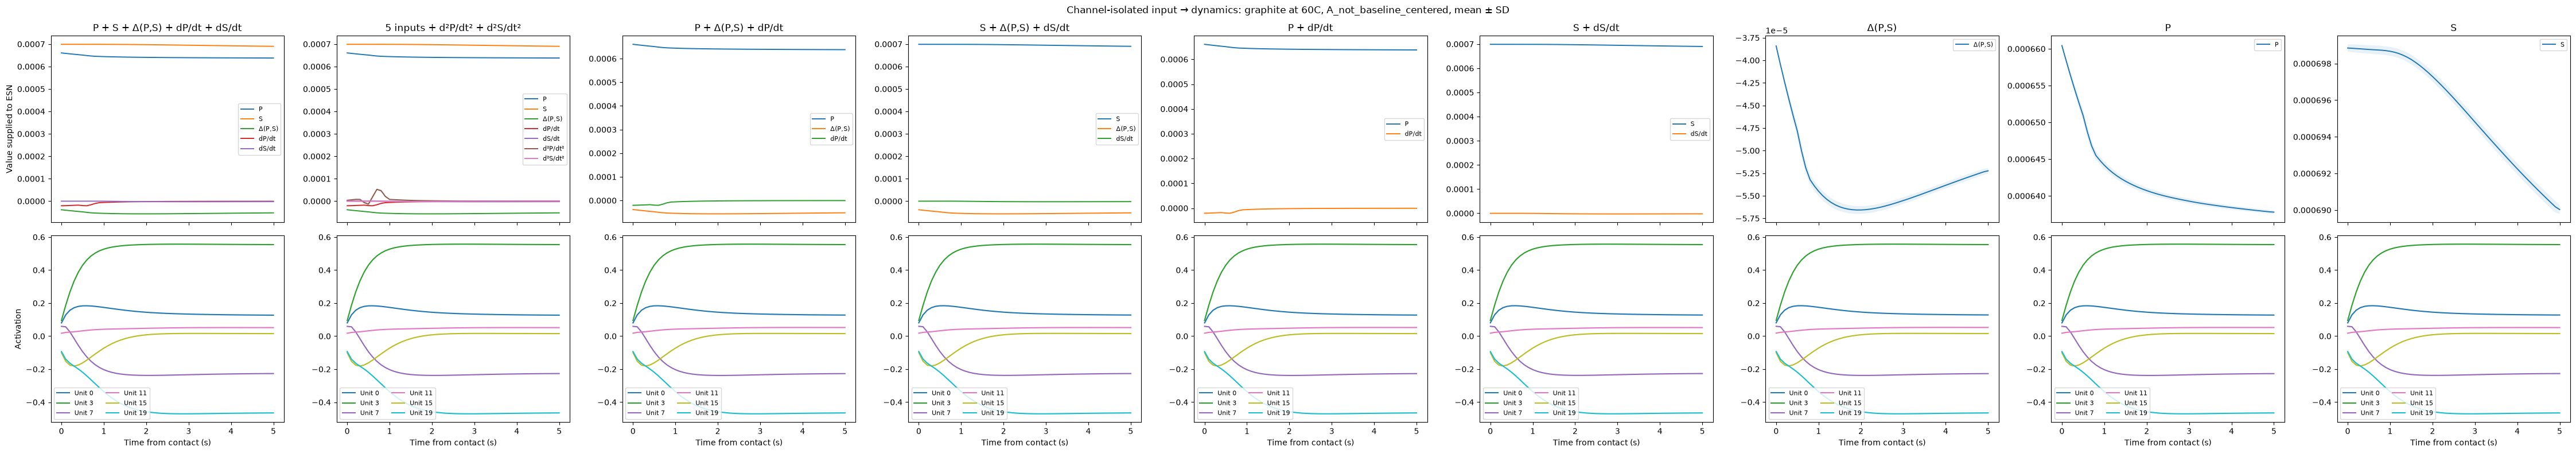

Saved channel-isolation outputs to: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation


In [115]:
# Condition A dynamics diagnostic for the channel-isolation question.
CHANNEL_DIAGNOSTIC_CONDITION = "A_not_baseline_centered"
CHANNEL_DIAGNOSTIC_MATERIAL = "graphite"
CHANNEL_DIAGNOSTIC_TEMPERATURE = "60C"
CHANNEL_DIAGNOSTIC_SEED = 42
CHANNEL_DIAGNOSTIC_UNITS = (0, 3, 7, 11, 15, 19)
channel_grid = np.linspace(*ANALYSIS_WINDOW, 101)
channel_selected = (METADATA[(METADATA["Sample"] == CHANNEL_DIAGNOSTIC_MATERIAL)
                             & (METADATA["Temperature"] == CHANNEL_DIAGNOSTIC_TEMPERATURE)]
                    .sort_values("Trial"))
if channel_selected.empty:
    raise KeyError("Requested channel diagnostic material/temperature was not found.")

fig, axes = plt.subplots(2, 9, figsize=(45, 8), sharex=True)
input_mode = CONDITIONS[CHANNEL_DIAGNOSTIC_CONDITION]
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(CHANNEL_DIAGNOSTIC_UNITS)))
for column, channel_set in enumerate(channel_order):
    spec = CHANNEL_SETS[channel_set]
    input_trials, state_trials = [], []
    for trial_id in channel_selected["trial_id"]:
        trial = aligned_trials[trial_id]
        time = trial["time_from_contact"].to_numpy(float)
        represented = esn_input(trial, input_mode)
        full_input = np.column_stack([
            represented, np.gradient(represented[:, 3], time), np.gradient(represented[:, 4], time)
        ])
        selected_input = full_input[:, spec["sequence_columns"]]
        states = ChannelMatchedReservoir(CHANNEL_DIAGNOSTIC_SEED).run(full_input, spec)
        input_trials.append(np.column_stack([np.interp(channel_grid, time, selected_input[:, j])
                                             for j in range(selected_input.shape[1])]))
        state_trials.append(np.column_stack([np.interp(channel_grid, time, states[:, unit])
                                             for unit in CHANNEL_DIAGNOSTIC_UNITS]))
    input_stack, state_stack = np.asarray(input_trials), np.asarray(state_trials)
    input_mean, input_sd = input_stack.mean(axis=0), input_stack.std(axis=0, ddof=1)
    state_mean, state_sd = state_stack.mean(axis=0), state_stack.std(axis=0, ddof=1)
    input_names = ({
        "P_S_delta_dP_dS": ["P", "S", "Δ(P,S)", "dP/dt", "dS/dt"],
        "P_S_delta_dP_dS_ddP_ddS": ["P", "S", "Δ(P,S)", "dP/dt", "dS/dt",
                                           "d²P/dt²", "d²S/dt²"],
        "P_delta_dP": ["P", "Δ(P,S)", "dP/dt"],
        "S_delta_dS": ["S", "Δ(P,S)", "dS/dt"],
        "P_dP": ["P", "dP/dt"], "S_dS": ["S", "dS/dt"],
        "delta": ["Δ(P,S)"],
        "P": ["P"], "S": ["S"],
    })[channel_set]
    for j, name in enumerate(input_names):
        axes[0, column].plot(channel_grid, input_mean[:, j], linewidth=1.4, label=name)
        axes[0, column].fill_between(channel_grid, input_mean[:, j]-input_sd[:, j],
                                     input_mean[:, j]+input_sd[:, j], alpha=0.10)
    for j, unit in enumerate(CHANNEL_DIAGNOSTIC_UNITS):
        axes[1, column].plot(channel_grid, state_mean[:, j], color=unit_colors[j], label=f"Unit {unit}")
        axes[1, column].fill_between(channel_grid, state_mean[:, j]-state_sd[:, j],
                                     state_mean[:, j]+state_sd[:, j], color=unit_colors[j], alpha=0.10)
    axes[0, column].set_title(channel_labels[channel_set]); axes[0, column].legend(fontsize=8)
    axes[1, column].set_xlabel("Time from contact (s)"); axes[1, column].legend(fontsize=8, ncol=2)
axes[0, 0].set_ylabel("Value supplied to ESN"); axes[1, 0].set_ylabel("Activation")
fig.suptitle(f"Channel-isolated input → dynamics: {CHANNEL_DIAGNOSTIC_MATERIAL} at "
             f"{CHANNEL_DIAGNOSTIC_TEMPERATURE}, {CHANNEL_DIAGNOSTIC_CONDITION}, mean ± SD")
plt.tight_layout(); plt.show()

CHANNEL_OOF.to_csv(RESULTS_DIR / f"{RESULT_STEM}_channel_isolation_oof_predictions.csv", index=False)
CHANNEL_OVERALL.to_csv(RESULTS_DIR / f"{RESULT_STEM}_channel_isolation_overall_metrics.csv", index=False)
CHANNEL_MATERIAL_METRICS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_channel_isolation_material_metrics.csv", index=False)
print("Saved channel-isolation outputs to:", RESULTS_DIR)


# 12. Save reproducible ablation outputs and provenance

In [116]:
OOF.to_csv(RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv", index=False)
FOLD_METRICS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv", index=False)
OVERALL.to_csv(RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv", index=False)
MATERIAL_MEANS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_material_means.csv", index=False)
MATERIAL_LEVEL_RESULTS.to_csv(RESULTS_DIR / f"{RESULT_STEM}_material_level_metrics.csv", index=False)

provenance = {
    "research_question": "Effect of three sensor scaling representations under fixed model settings",
    "conditions": {
        "A_not_baseline_centered": "u(t)",
        "B_baseline_centered": "u(t)-u(0)",
        "C_per_trial_minmax_-1_to_0": "(u(t)-max(u))/(max(u)-min(u)), separately per sensor and trial",
    },
    "analysis_window": list(ANALYSIS_WINDOW),
    "common_preprocessing": "Savitzky-Golay smoothing before the condition-specific transformation",
    "post_condition_scaler": None,
    "reservoir_representation": "nine nonredundant statistical summaries per unit",
    "regressor_inputs": ["summarized ESN trajectories only"],
    "esn_parameters": ESN_PARAMS, "xgb_parameters": XGB_PARAMS,
    "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO with pooled OOF metrics",
    "clip_predictions_to_training_range": CLIP_PREDICTIONS_TO_TRAIN_RANGE,
}
with (RESULTS_DIR / f"{RESULT_STEM}_provenance.json").open("w") as file:
    json.dump(provenance, file, indent=2)
print("Saved results to:", RESULTS_DIR)


Saved results to: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation


# 13. Interpretation checklist

1. Compare pooled NRMSE and $R^2$; neither metric alone establishes improvement.
2. Inspect paired per-material NRMSE differences. A negative centered-minus-uncentered difference favors centering.
3. Check whether centering or per-trial normalization changes input separation, reservoir activation, or saturation.
4. Check whether any pooled improvement is widespread or driven by only a few high-effusivity materials.
5. Report predictor counts, fixed HPs, folds, and seeds with the results.
6. Conclude only that a preprocessing treatment helped or hurt **under this fixed reference model**; this is not a comparison of independently optimized pipelines.
7. Condition C deliberately removes absolute per-trial amplitude. If it performs worse, amplitude likely carried useful effusivity information; if it performs better, relative trajectory shape may be more useful than absolute magnitude.